# Supply Chain Scenario Simulation Engine (Monte Carlo + Stress Testing)
This notebook provides a comprehensive Supply Chain Scenario Simulation Engine designed for uncertainty analysis using Monte Carlo simulations and stress testing. It models key variables such as demand volatility, lead time variability, and cost fluctuations under multiple predefined scenarios (Base, High Demand, Supply Delay, Capacity Constraint, Cost Shock).

The primary objective is to measure critical performance indicators including risk exposure, service level, and profitability under various uncertain conditions. The insights generated from this simulation form the backbone for informed decision-making and can be used to populate interactive dashboards in tools like Excel and Power BI.

**What this section will do:**

*   Simulate random demand using a normal distribution.
*   Simulate lead time variability.
*   Calculate inventory depletion over time.

**Key Performance Indicators (KPIs) measured:**

*   Stockouts
*   Total Cost
*   Service Level
*   Profit Impact
*   Comparison across multiple stress scenarios

# 1.1 Import Libraries & Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# 1.2 Load Dataset

Step A: Paste data manually

In [2]:
from io import StringIO

data = """Scenario,Product,Demand_Mean,Demand_Std,LeadTime_Days,LeadTime_Var,Warehouse_Capacity,Transport_Cost_per_Unit,Unit_Cost,Stockout_Cost,Initial_Inventory
Base,P1,1000,80,5,1,5000,2.5,10,25,1200
Base,P2,800,60,4,1,5000,2.0,8,20,900
Base,P3,600,50,6,2,5000,3.0,12,30,700
HighDemand,P1,1300,120,5,1,5000,2.5,10,25,1200
HighDemand,P2,1050,100,4,1,5000,2.0,8,20,900
HighDemand,P3,900,90,6,2,5000,3.0,12,30,700
SupplyDelay,P1,1000,80,8,2,5000,2.5,10,25,1200
SupplyDelay,P2,800,60,7,2,5000,2.0,8,20,900
SupplyDelay,P3,600,50,9,3,5000,3.0,12,30,700
CapacityConstraint,P1,1000,80,5,1,3000,2.5,10,25,1200
CapacityConstraint,P2,800,60,4,1,3000,2.0,8,20,900
CapacityConstraint,P3,600,50,6,2,3000,3.0,12,30,700
CostShock,P1,1000,80,5,1,5000,3.5,12,25,1200
CostShock,P2,800,60,4,1,5000,2.8,10,20,900
CostShock,P3,600,50,6,2,5000,4.0,14,30,700
"""

df = pd.read_csv(StringIO(data))
df.head()

,Scenario,Product,Demand_Mean,Demand_Std,LeadTime_Days,LeadTime_Var,Warehouse_Capacity,Transport_Cost_per_Unit,Unit_Cost,Stockout_Cost,Initial_Inventory
0,Base,P1,1000,80,5,1,5000,2.5,10,25,1200
1,Base,P2,800,60,4,1,5000,2.0,8,20,900
2,Base,P3,600,50,6,2,5000,3.0,12,30,700
3,HighDemand,P1,1300,120,5,1,5000,2.5,10,25,1200
4,HighDemand,P2,1050,100,4,1,5000,2.0,8,20,900


Step B: Quick validation

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Scenario                 15 non-null     object 
 1   Product                  15 non-null     object 
 2   Demand_Mean              15 non-null     int64  
 3   Demand_Std               15 non-null     int64  
 4   LeadTime_Days            15 non-null     int64  
 5   LeadTime_Var             15 non-null     int64  
 6   Warehouse_Capacity       15 non-null     int64  
 7   Transport_Cost_per_Unit  15 non-null     float64
 8   Unit_Cost                15 non-null     int64  
 9   Stockout_Cost            15 non-null     int64  
 10  Initial_Inventory        15 non-null     int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 1.4+ KB


,0
Scenario,0
Product,0
Demand_Mean,0
Demand_Std,0
LeadTime_Days,0
LeadTime_Var,0
Warehouse_Capacity,0
Transport_Cost_per_Unit,0
Unit_Cost,0
Stockout_Cost,0


# 1.3 Simulation Engine (Monte Carlo Core)

Step A: Simulation parameters

In [4]:
np.random.seed(42)
n_simulations = 1000

Step B: Monte Carlo simulation function

In [5]:
def run_simulation(row):
    demand = np.random.normal(row["Demand_Mean"], row["Demand_Std"], n_simulations)
    lead_time = np.random.normal(row["LeadTime_Days"], row["LeadTime_Var"], n_simulations)

    inventory = row["Initial_Inventory"]

    stockouts = []
    unmet_demand = []

    for i in range(n_simulations):
        if demand[i] > inventory:
            stockouts.append(1)
            unmet_demand.append(demand[i] - inventory)
        else:
            stockouts.append(0)
            unmet_demand.append(0)

    return pd.Series({
        "Stockout_Probability": np.mean(stockouts),
        "Avg_Unmet_Demand": np.mean(unmet_demand)
    })

Step C: Run simulation for all scenarios

In [6]:
results = df.join(df.apply(run_simulation, axis=1))
results

,Scenario,Product,Demand_Mean,Demand_Std,LeadTime_Days,LeadTime_Var,Warehouse_Capacity,Transport_Cost_per_Unit,Unit_Cost,Stockout_Cost,Initial_Inventory,Stockout_Probability,Avg_Unmet_Demand
0,Base,P1,1000,80,5,1,5000,2.5,10,25,1200,0.007,0.195563
1,Base,P2,800,60,4,1,5000,2.0,8,20,900,0.047,1.189800
2,Base,P3,600,50,6,2,5000,3.0,12,30,700,0.016,0.330561
3,HighDemand,P1,1300,120,5,1,5000,2.5,10,25,1200,0.777,111.119136
4,HighDemand,P2,1050,100,4,1,5000,2.0,8,20,900,0.932,154.909004
5,HighDemand,P3,900,90,6,2,5000,3.0,12,30,700,0.986,196.907132
6,SupplyDelay,P1,1000,80,8,2,5000,2.5,10,25,1200,0.006,0.165537
7,SupplyDelay,P2,800,60,7,2,5000,2.0,8,20,900,0.054,1.308126
8,SupplyDelay,P3,600,50,9,3,5000,3.0,12,30,700,0.024,0.388750
9,CapacityConstraint,P1,1000,80,5,1,3000,2.5,10,25,1200,0.008,0.266239


# 1.4 KPI Output Generator

Step A: Upgrade simulation output

In [7]:
def run_kpis(row):
    demand = np.random.normal(row["Demand_Mean"], row["Demand_Std"], n_simulations)

    inventory = row["Initial_Inventory"]

    stockouts = demand > inventory
    unmet = np.maximum(demand - inventory, 0)

    filled_demand = np.minimum(demand, inventory)

    revenue_loss = unmet * row["Stockout_Cost"]
    transport_cost = demand * row["Transport_Cost_per_Unit"]
    production_cost = demand * row["Unit_Cost"]

    return pd.Series({
        "Stockout_Rate": stockouts.mean(),
        "Service_Level": filled_demand.mean() / demand.mean(),
        "Avg_Unmet_Demand": unmet.mean(),
        "Avg_Total_Cost": (revenue_loss + transport_cost + production_cost).mean()
    })

Step B: Apply KPI engine

In [8]:
kpi_results = df.join(df.apply(run_kpis, axis=1))
kpi_results

,Scenario,Product,Demand_Mean,Demand_Std,LeadTime_Days,LeadTime_Var,Warehouse_Capacity,Transport_Cost_per_Unit,Unit_Cost,Stockout_Cost,Initial_Inventory,Stockout_Rate,Service_Level,Avg_Unmet_Demand,Avg_Total_Cost
0,Base,P1,1000,80,5,1,5000,2.5,10,25,1200,0.011,0.999751,0.249486,12534.658592
1,Base,P2,800,60,4,1,5000,2.0,8,20,900,0.046,0.998776,0.977289,8006.922345
2,Base,P3,600,50,6,2,5000,3.0,12,30,700,0.028,0.998922,0.644372,8986.738898
3,HighDemand,P1,1300,120,5,1,5000,2.5,10,25,1200,0.793,0.909512,118.040057,19257.071028
4,HighDemand,P2,1050,100,4,1,5000,2.0,8,20,900,0.922,0.858061,148.241931,13408.901007
5,HighDemand,P3,900,90,6,2,5000,3.0,12,30,700,0.985,0.780956,196.221105,19323.759853
6,SupplyDelay,P1,1000,80,8,2,5000,2.5,10,25,1200,0.007,0.999899,0.101259,12513.632791
7,SupplyDelay,P2,800,60,7,2,5000,2.0,8,20,900,0.031,0.999201,0.635970,7974.650346
8,SupplyDelay,P3,600,50,9,3,5000,3.0,12,30,700,0.022,0.999380,0.372687,9025.807559
9,CapacityConstraint,P1,1000,80,5,1,3000,2.5,10,25,1200,0.009,0.999743,0.258500,12564.796945


# Clean output for Excel / Power BI

In [9]:
final_output = kpi_results[[
    "Scenario",
    "Product",
    "Stockout_Rate",
    "Service_Level",
    "Avg_Unmet_Demand",
    "Avg_Total_Cost"
]]

final_output

,Scenario,Product,Stockout_Rate,Service_Level,Avg_Unmet_Demand,Avg_Total_Cost
0,Base,P1,0.011,0.999751,0.249486,12534.658592
1,Base,P2,0.046,0.998776,0.977289,8006.922345
2,Base,P3,0.028,0.998922,0.644372,8986.738898
3,HighDemand,P1,0.793,0.909512,118.040057,19257.071028
4,HighDemand,P2,0.922,0.858061,148.241931,13408.901007
5,HighDemand,P3,0.985,0.780956,196.221105,19323.759853
6,SupplyDelay,P1,0.007,0.999899,0.101259,12513.632791
7,SupplyDelay,P2,0.031,0.999201,0.635970,7974.650346
8,SupplyDelay,P3,0.022,0.999380,0.372687,9025.807559
9,CapacityConstraint,P1,0.009,0.999743,0.258500,12564.796945


Converting the final_output into CSV file

In [10]:
df_final_output = final_output.to_csv('advanced_scenario_simulation.csv', index=False)

# Task
The goal is to perform a comprehensive analysis of the simulation results by visualizing key performance indicators (KPIs) across different scenarios and products. This analysis will include generating grouped bar charts for 'Service Level' and 'Average Total Cost', a heatmap for KPI correlations, a summary table for best/worst product performance, and a pivot table for scenario summaries. Finally, I will provide a detailed explanation and justification for each visualization type.

## Analyze KPI Results

### Subtask:
Review the `kpi_results` DataFrame, which includes 'Scenario', 'Product', 'Stockout_Rate', 'Service_Level', 'Avg_Unmet_Demand', and 'Avg_Total_Cost', to understand the structure and nature of the data.


**Reasoning**:
To understand the distribution and range of values for each KPI, I will display descriptive statistics of the numerical columns in the `kpi_results` DataFrame.



In [11]:
print('Descriptive Statistics of KPI Results:')
kpi_results.describe()

Descriptive Statistics of KPI Results:


,Demand_Mean,Demand_Std,LeadTime_Days,LeadTime_Var,Warehouse_Capacity,Transport_Cost_per_Unit,Unit_Cost,Stockout_Cost,Initial_Inventory,Stockout_Rate,Service_Level,Avg_Unmet_Demand,Avg_Total_Cost
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,856.666667,71.333333,5.600000,1.533333,4600.000000,2.686667,10.400000,25.000000,933.333333,0.199267,0.969353,31.246246,11818.180681
std,206.039756,20.998866,1.502379,0.639940,828.078671,0.586596,1.882248,4.225771,212.692490,0.364808,0.066673,65.340599,3779.149937
min,600.000000,50.000000,4.000000,1.000000,3000.000000,2.000000,8.000000,20.000000,700.000000,0.007000,0.780956,0.101259,7974.650346
25%,700.000000,55.000000,4.500000,1.000000,5000.000000,2.250000,9.000000,20.000000,700.000000,0.011000,0.998673,0.253993,9006.273229
50%,800.000000,60.000000,5.000000,1.000000,5000.000000,2.500000,10.000000,25.000000,900.000000,0.028000,0.999201,0.635970,10824.836254
75%,1000.000000,80.000000,6.000000,2.000000,5000.000000,3.000000,12.000000,30.000000,1200.000000,0.047000,0.999703,1.062791,12986.848976
max,1300.000000,120.000000,9.000000,3.000000,5000.000000,4.000000,14.000000,30.000000,1200.000000,0.985000,0.999899,196.221105,19323.759853


## Suggest Grouped Bar Chart for Service Level

### Subtask:
Propose a grouped bar chart to visualize 'Service_Level' across different 'Scenarios' and 'Products', as this is effective for comparing a metric across two categorical variables. I will make sure to provide legends in the plot.


**Reasoning**:
Generate a grouped bar chart to visualize 'Service_Level' across different 'Scenarios' and 'Products' to compare service levels visually.



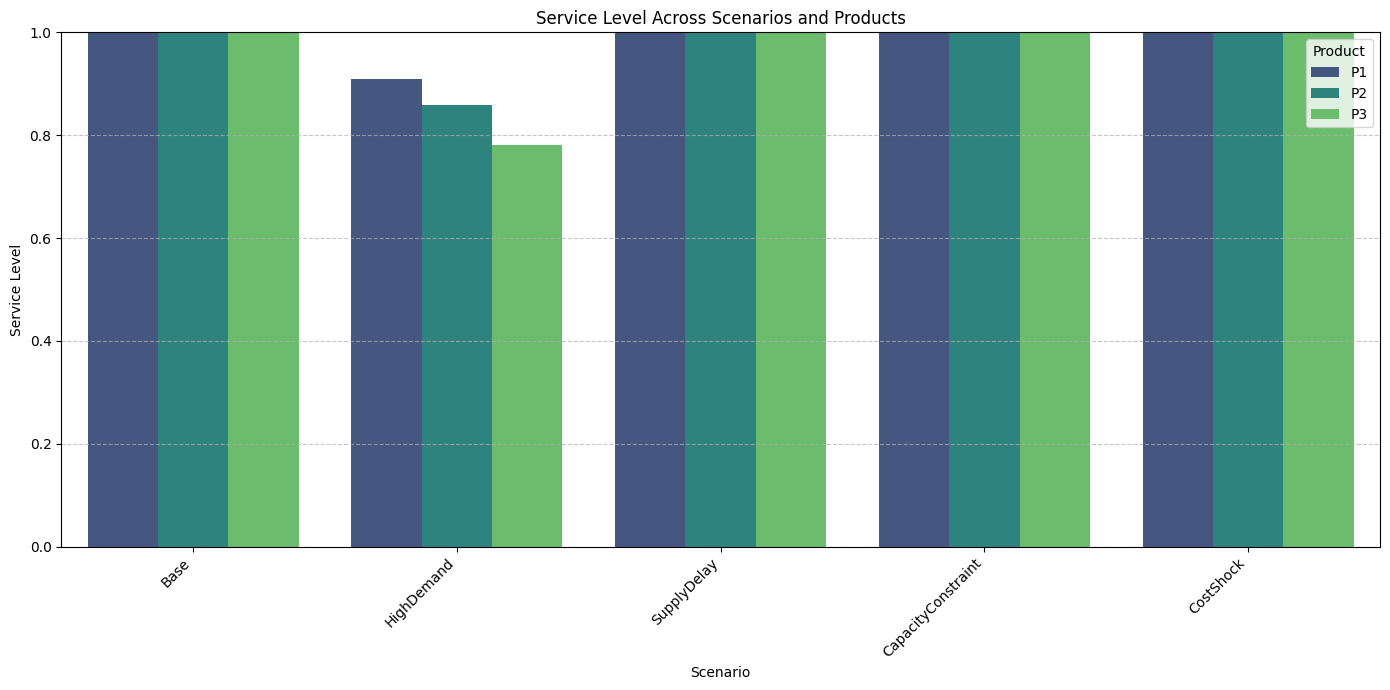

Grouped bar chart for Service Level displayed.


In [12]:
import seaborn as sns

# Prepare the data for plotting
plot_data = kpi_results[['Scenario', 'Product', 'Service_Level']]

# Create the grouped bar chart
plt.figure(figsize=(14, 7))
sns.barplot(x='Scenario', y='Service_Level', hue='Product', data=plot_data, palette='viridis')

# Add labels and title
plt.xlabel('Scenario')
plt.ylabel('Service Level')
plt.title('Service Level Across Scenarios and Products')
plt.ylim(0, 1) # Service level is typically between 0 and 1
plt.legend(title='Product')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Grouped bar chart for Service Level displayed.")

## Suggest Grouped Bar Chart for Avg Total Cost

### Subtask:
Propose another grouped bar chart to display 'Avg_Total_Cost' by 'Scenario' and 'Product', offering a clear comparison of costs under various conditions. I will make sure to provide legends in the plot.


**Reasoning**:
This code block generates a grouped bar chart for 'Avg_Total_Cost' across different scenarios and products, fulfilling the current subtask's visualization requirement.



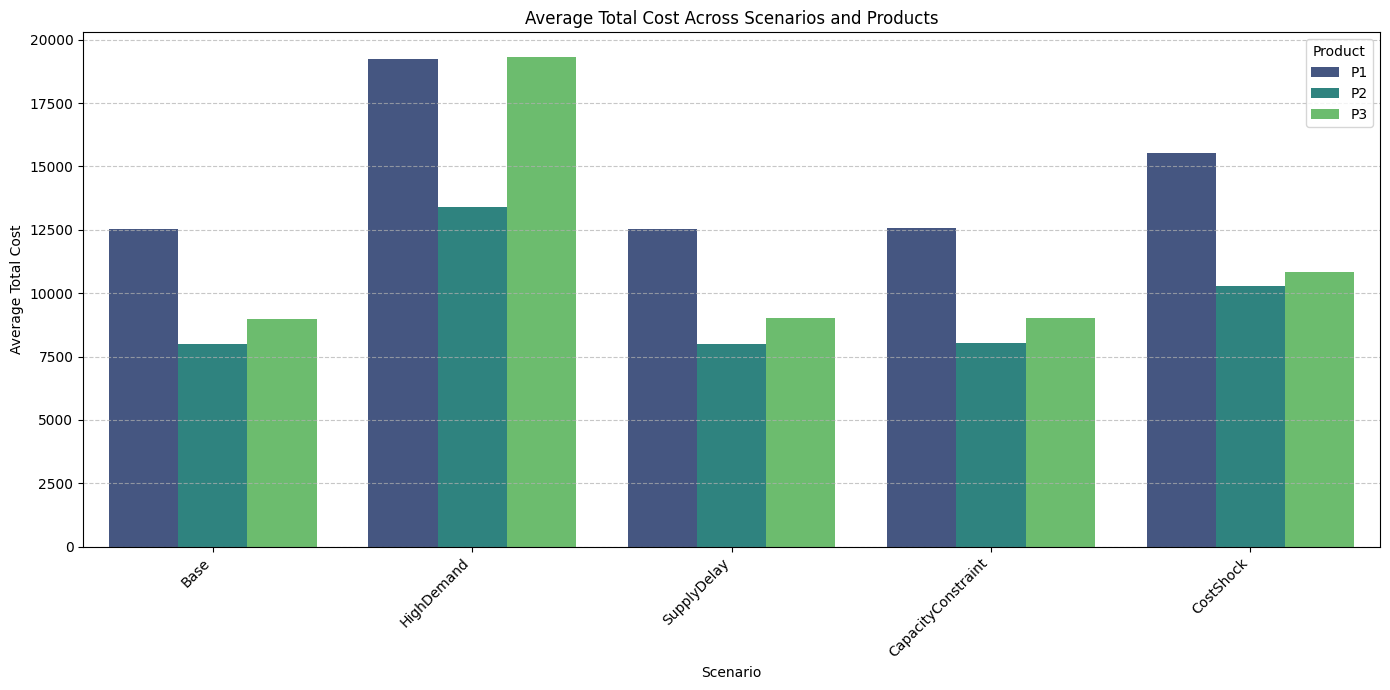

Grouped bar chart for Average Total Cost displayed.


In [13]:
import seaborn as sns

# Prepare the data for plotting
plot_data_cost = kpi_results[['Scenario', 'Product', 'Avg_Total_Cost']]

# Create the grouped bar chart
plt.figure(figsize=(14, 7))
sns.barplot(x='Scenario', y='Avg_Total_Cost', hue='Product', data=plot_data_cost, palette='viridis')

# Add labels and title
plt.xlabel('Scenario')
plt.ylabel('Average Total Cost')
plt.title('Average Total Cost Across Scenarios and Products')
plt.legend(title='Product')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Grouped bar chart for Average Total Cost displayed.")

## Suggest Heatmap for KPI Correlations

### Subtask:
Propose a heatmap to visualize the correlation between key KPI metrics ('Stockout_Rate', 'Service_Level', 'Avg_Unmet_Demand', 'Avg_Total_Cost'), which can reveal relationships between them. I will make sure to provide legends in the plot.


**Reasoning**:
To visualize the correlation between the specified KPIs, I need to select the relevant columns, calculate their correlation matrix, and then plot it as a heatmap with annotations and a descriptive title.



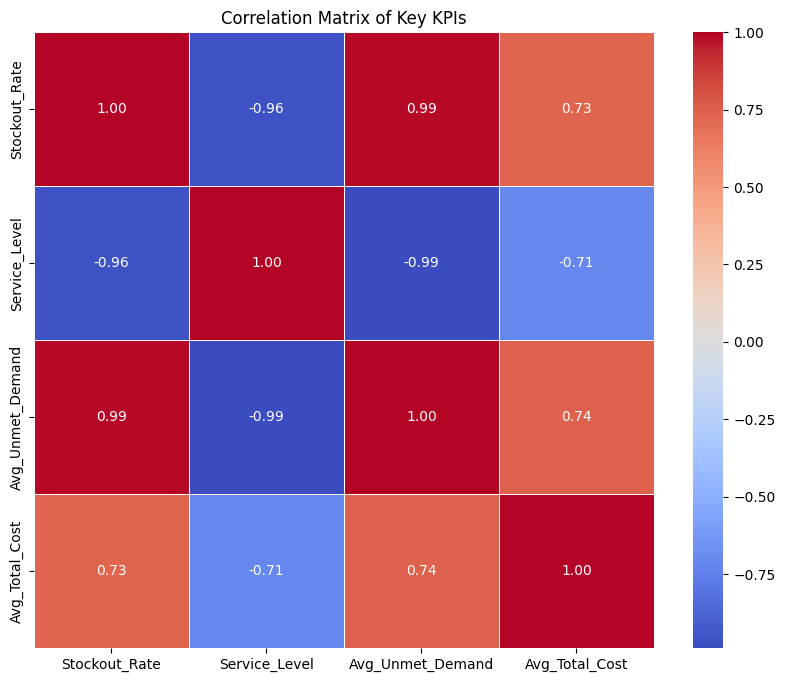

Heatmap for KPI correlations displayed.


In [14]:
import seaborn as sns

# Select the relevant KPI columns
kpi_columns = ['Stockout_Rate', 'Service_Level', 'Avg_Unmet_Demand', 'Avg_Total_Cost']
kpi_data = kpi_results[kpi_columns]

# Calculate the correlation matrix
correlation_matrix = kpi_data.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Add title
plt.title('Correlation Matrix of Key KPIs')
plt.show()
print("Heatmap for KPI correlations displayed.")

## Suggest Summary Table for Best/Worst Performance

### Subtask:
Propose generating a summary table that highlights the best and worst-performing products based on selected KPIs, providing a concise overview of product performance under different scenarios.


**Reasoning**:
To create the summary table, I need to iterate through each scenario and calculate the best and worst performing products for 'Service_Level', 'Stockout_Rate', and 'Avg_Total_Cost' based on their respective optimization goals (max for service level, min for stockout rate and total cost).



In [15]:
summary_data = []
kpis_to_analyze = {
    'Service_Level': {'best': 'max', 'worst': 'min'},
    'Stockout_Rate': {'best': 'min', 'worst': 'max'},
    'Avg_Total_Cost': {'best': 'min', 'worst': 'max'}
}

for scenario in kpi_results['Scenario'].unique():
    scenario_df = kpi_results[kpi_results['Scenario'] == scenario]

    for kpi, modes in kpis_to_analyze.items():
        # Best performance
        if modes['best'] == 'max':
            best_performance = scenario_df.loc[scenario_df[kpi].idxmax()]
        else: # min
            best_performance = scenario_df.loc[scenario_df[kpi].idxmin()]
        summary_data.append({
            'Scenario': scenario,
            'KPI': kpi,
            'Performance': 'Best',
            'Product': best_performance['Product'],
            'Value': best_performance[kpi]
        })

        # Worst performance
        if modes['worst'] == 'max':
            worst_performance = scenario_df.loc[scenario_df[kpi].idxmax()]
        else: # min
            worst_performance = scenario_df.loc[scenario_df[kpi].idxmin()]
        summary_data.append({
            'Scenario': scenario,
            'KPI': kpi,
            'Performance': 'Worst',
            'Product': worst_performance['Product'],
            'Value': worst_performance[kpi]
        })

best_worst_summary_df = pd.DataFrame(summary_data)
print("Summary table for best/worst performance generated.")
best_worst_summary_df

Summary table for best/worst performance generated.


,Scenario,KPI,Performance,Product,Value
0,Base,Service_Level,Best,P1,0.999751
1,Base,Service_Level,Worst,P2,0.998776
2,Base,Stockout_Rate,Best,P1,0.011000
3,Base,Stockout_Rate,Worst,P2,0.046000
4,Base,Avg_Total_Cost,Best,P2,8006.922345
5,Base,Avg_Total_Cost,Worst,P1,12534.658592
6,HighDemand,Service_Level,Best,P1,0.909512
7,HighDemand,Service_Level,Worst,P3,0.780956
8,HighDemand,Stockout_Rate,Best,P1,0.793000
9,HighDemand,Stockout_Rate,Worst,P3,0.985000


## Suggest Pivot Table for Scenario Summary

### Subtask:
Propose a pivot table to summarize KPI metrics by 'Scenario', allowing for easy comparison of overall performance across the different simulated conditions.


**Reasoning**:
To summarize the KPI metrics by scenario, I will create a pivot table using the `kpi_results` DataFrame, with 'Scenario' as the index and the specified KPI metrics as values aggregated by their mean.



In [16]:
scenario_summary_pivot = kpi_results.pivot_table(
    index='Scenario',
    values=['Stockout_Rate', 'Service_Level', 'Avg_Unmet_Demand', 'Avg_Total_Cost'],
    aggfunc='mean'
)
print("Pivot table summarizing KPI metrics by Scenario:")
scenario_summary_pivot

Pivot table summarizing KPI metrics by Scenario:


,Avg_Total_Cost,Avg_Unmet_Demand,Service_Level,Stockout_Rate
Scenario,,,,
Base,9842.773279,0.623716,0.999150,0.028333
CapacityConstraint,9878.376198,0.595807,0.999217,0.025667
CostShock,12201.813066,0.474036,0.999395,0.022333
HighDemand,17329.910629,154.167698,0.849510,0.900000
SupplyDelay,9838.030232,0.369972,0.999493,0.020000


## Final Task

### Subtask:
Provide a comprehensive explanation and justification for each of the five suggested visualization types, outlining their benefits for this project.
